In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload

import robust_filter

reload(robust_filter)

from data_processing import daily_stock_variance
from robust_filter import Filter, score_func, kalman_func
from parameter_estimation import generate_param_grid, grid_search

Data preparation

In [27]:
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "bin201901.csv"
DATA_PATH

PosixPath('/Users/elsaemiliabodle/VSCodeProjects/robust-filtering/data/bin201901.csv')

In [28]:
df = pd.read_csv(DATA_PATH)

In [29]:
df_subset = df[df["stock"] == "AAPL"]
df_subset.head()

,date,time,stock,trade,orderFlow,hidden,auction,mid,midEnd,spread,effSpread,lobImb,effLobImb,trdLiq,ofLiq,depth,nbEvents,nbHidden,nbTrades
6627,2019-01-02,09:30:00,AAPL,-11855,-14141,12397,419249,154.915,154.755,0.055,0.156354,0.866667,0.261039,18657,68751,277.6250,8,1,2
6628,2019-01-02,09:30:10,AAPL,527,3346,4579,0,154.640,154.645,0.070,0.055760,0.000000,-0.659986,11359,42698,313.8571,7,1,2
6629,2019-01-02,09:30:20,AAPL,-2979,7161,1765,0,154.595,154.605,0.045,0.041798,0.333333,-0.010202,6573,78475,337.6250,8,1,2
6630,2019-01-02,09:30:30,AAPL,5120,12162,1663,0,154.600,154.620,0.010,0.015000,0.666667,0.703877,7322,106242,897.1111,9,1,2
6631,2019-01-02,09:30:40,AAPL,8889,29297,1038,0,154.885,154.875,0.035,0.029257,0.760000,0.640284,12651,126539,831.2500,8,1,2


In [30]:
# Compute intraday variance per day per stock
var_df = daily_stock_variance(
    df_subset, date_col="date", stock_col="stock", value_col="mid"
)
var_df.head(10)

,date,stock,mid_var
0,2019-01-02,AAPL,1.254937
1,2019-01-03,AAPL,0.831683
2,2019-01-04,AAPL,0.968374
3,2019-01-07,AAPL,0.340471
4,2019-01-08,AAPL,0.669532
5,2019-01-09,AAPL,0.236284
6,2019-01-10,AAPL,0.370574
7,2019-01-11,AAPL,0.182443
8,2019-01-14,AAPL,0.060622
9,2019-01-15,AAPL,0.376290


Real data: Intraday variance observations

In [31]:
# Extract variance observations as list (mean variance across all days)
y = var_df["mid_var"].values.tolist()
N = len(y)

print(f"Number of observations: {N}")
print(f"Observation mean: {np.mean(y):.6f}")
print(f"Observation std: {np.std(y):.6f}")
print(f"Observation min: {np.min(y):.6f}, max: {np.max(y):.6f}")
print(f"First 5 observations: {y[:5]}")

Number of observations: 21
Observation mean: 0.560049
Observation std: 0.426123
Observation min: 0.060622, max: 1.898497
First 5 observations: [1.254937433535907, 0.8316834178350951, 0.9683738066683377, 0.3404712951467236, 0.6695322685933907]


Parameter estimation

In [32]:
# Parameter grid for actual variance data
# Adjust ranges based on observed variance statistics
sigma_obs = np.std(y)
param_grid = {
    "nu": np.arange(4, 15, 1),  # Degrees of freedom for Student-t
    "sigma": np.linspace(
        sigma_obs * 0.2, sigma_obs * 1.5, 6
    ),  # Measurement noise scale
    "theta": np.linspace(0.5, 0.99, 5),  # State persistence (AR(1) coefficient)
    "kappa": np.linspace(0.05, 0.5, 5),  # Measurement update gain
}
param_dicts = generate_param_grid(param_grid)
print(f"Generated {len(param_dicts)} parameter combinations for grid search")

Generated 1650 parameter combinations for grid search


In [33]:
# Grid search for score filter (robust to outliers)
print("Grid search for Score filter...")
best_params_score = grid_search(
    y, mu_0=np.median(y), param_dicts=param_dicts, func=score_func
)
print(f"✓ Score filter grid search completed")
print(f"  Best params: {best_params_score}")

Grid search for Score filter...
✓ Score filter grid search completed
  Best params: {'nu': np.int64(5), 'sigma': np.float64(0.30680868930415), 'theta': np.float64(0.99), 'kappa': np.float64(0.5)}


In [34]:
# Fit score filter with best parameters
score_filter = Filter(mu_0=np.median(y), param_dict=best_params_score, func=score_func)
score_filter.update(y)
print(
    f"✓ Score filter fitted, state range: [{np.min(score_filter.mu):.6f}, {np.max(score_filter.mu):.6f}]"
)

✓ Score filter fitted, state range: [0.184488, 0.790519]


In [35]:
# Grid search for Kalman filter (Gaussian residuals) - only theta and kappa
# Kalman doesn't use nu/sigma, so optimize over theta and kappa only
param_grid_kalman = {
    "theta": np.linspace(0.5, 0.99, 5),
    "kappa": np.linspace(0.05, 0.5, 5),
}
param_dicts_kalman = generate_param_grid(param_grid_kalman)

print("Grid search for Kalman filter...")
best_params_kalman = grid_search(
    y, mu_0=np.median(y), param_dicts=param_dicts_kalman, func=kalman_func
)
print(f"✓ Kalman filter grid search completed")
print(f"  Best params: {best_params_kalman}")

Grid search for Kalman filter...


KeyError: 'nu'

In [ ]:
# Fit Kalman filter with best parameters
kalman_filter = Filter(mu_0=np.median(y), param_dict=best_params_kalman)
kalman_filter.update(y)
print(
    f"✓ Kalman filter fitted, state range: [{np.min(kalman_filter.mu):.6f}, {np.max(kalman_filter.mu):.6f}]"
)

✓ Kalman filter fitted, state range: [0.126160, 0.935368]


In [ ]:
# Likelihood surface: Score filter (sigma, nu) with optimal theta, kappa
from parameter_estimation import log_likelihood

# Create grid for sigma and nu (hold theta, kappa at their best values)
sigma_grid = np.linspace(
    best_params_score["sigma"] * 0.5, best_params_score["sigma"] * 2.0, 20
)
nu_grid = np.arange(4, 20, 1)

ll_surface_score = np.zeros((len(nu_grid), len(sigma_grid)))

for i, nu in enumerate(nu_grid):
    for j, sigma in enumerate(sigma_grid):
        # Create parameter dict with fixed theta, kappa and varying sigma, nu
        param_dict = {
            "theta": best_params_score["theta"],
            "kappa": best_params_score["kappa"],
            "sigma": sigma,
            "nu": nu,
        }
        filt = Filter(mu_0=np.median(y), param_dict=param_dict, func=score_func)
        filt.update(y)
        ll_surface_score[i, j] = log_likelihood(filt.mu_prior, y, param_dict)

# Plot likelihood surface for Score filter
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
X, Y = np.meshgrid(sigma_grid, nu_grid)
ax.plot_surface(X, Y, ll_surface_score, cmap="viridis", alpha=0.8, edgecolor="none")
ax.set_xlabel("Sigma (measurement noise)")
ax.set_ylabel("Nu (degrees of freedom)")
ax.set_zlabel("Log-likelihood")
ax.set_title(
    f"Score Filter Likelihood Surface (theta={best_params_score['theta']:.3f}, kappa={best_params_score['kappa']:.3f})"
)
plt.tight_layout()
plt.show()

print(
    f"Score filter likelihood surface max at nu={nu_grid[np.unravel_index(np.argmax(ll_surface_score), ll_surface_score.shape)[0]]}, sigma={sigma_grid[np.unravel_index(np.argmax(ll_surface_score), ll_surface_score.shape)[1]]:.6f}"
)

In [ ]:
# Likelihood surface: Kalman filter (theta, kappa)
# For Kalman, we only optimize theta and kappa (no nu/sigma)
# Kalman uses Gaussian assumption, so nu and sigma are implicit

theta_grid = np.linspace(0.5, 0.99, 25)
kappa_grid = np.linspace(0.05, 0.5, 25)

ll_surface_kalman = np.zeros((len(kappa_grid), len(theta_grid)))

for i, kappa in enumerate(kappa_grid):
    for j, theta in enumerate(theta_grid):
        # Create parameter dict with varying theta, kappa (no nu, sigma for Kalman)
        param_dict = {
            "theta": theta,
            "kappa": kappa,
        }
        filt = Filter(mu_0=np.median(y), param_dict=param_dict, func=kalman_func)
        filt.update(y)
        # For Kalman (Gaussian), we compute likelihood with implicit sigma=1, nu=inf
        # Use simple Gaussian likelihood: 0.5 * sum((y - mu_prior)^2)
        residuals = [y_t - mu_t for y_t, mu_t in zip(y, filt.mu_prior)]
        ll_surface_kalman[i, j] = -0.5 * np.sum(np.array(residuals) ** 2)

# Plot likelihood surface for Kalman filter
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
X_k, Y_k = np.meshgrid(theta_grid, kappa_grid)
ax.plot_surface(X_k, Y_k, ll_surface_kalman, cmap="plasma", alpha=0.8, edgecolor="none")
ax.set_xlabel("Theta (state persistence)")
ax.set_ylabel("Kappa (measurement gain)")
ax.set_zlabel("Negative SSR (Gaussian likelihood)")
ax.set_title("Kalman Filter Likelihood Surface")
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.argmax(ll_surface_kalman), ll_surface_kalman.shape)
print(
    f"Kalman filter likelihood surface max at theta={theta_grid[best_idx[1]]:.3f}, kappa={kappa_grid[best_idx[0]]:.3f}"
)

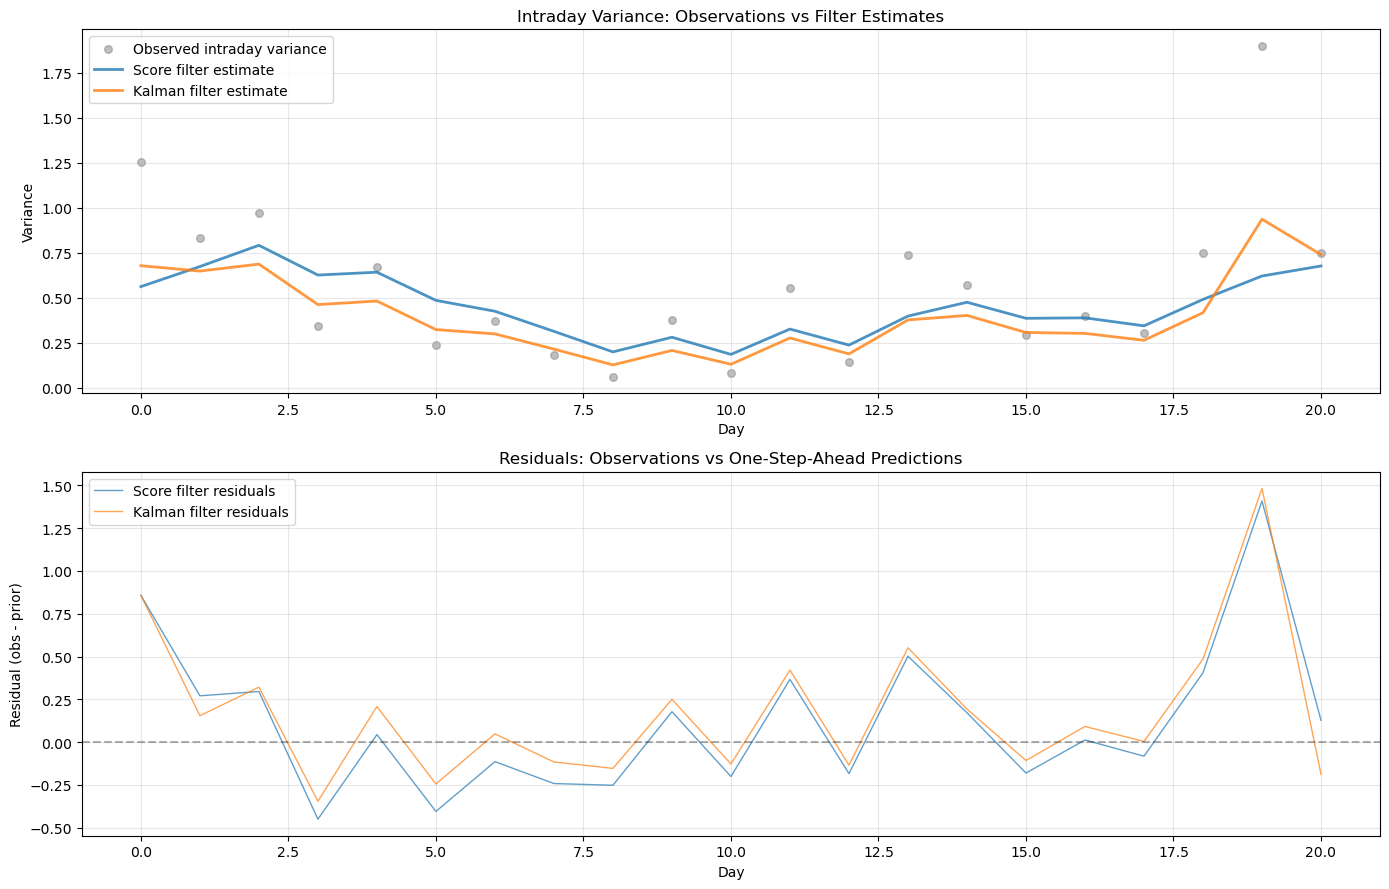


=== Filter Comparison ===
Score filter:  theta=0.990, kappa=0.500, sigma=0.3068, nu=5
Kalman filter: theta=0.867, kappa=0.388, sigma=0.3068, nu=4

Mean residual:
  Score:  0.120529
  Kalman: 0.173951
Std residual:
  Score:  0.426495
  Kalman: 0.413568


In [ ]:
# Plot results on actual intraday variance data
t = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Time series: observations and filter estimates
axes[0].scatter(t, y, label="Observed intraday variance", alpha=0.5, s=30, color="gray")
axes[0].plot(t, score_filter.mu, label="Score filter estimate", linewidth=2, alpha=0.8)
axes[0].plot(
    t, kalman_filter.mu, label="Kalman filter estimate", linewidth=2, alpha=0.8
)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Variance")
axes[0].set_title("Intraday Variance: Observations vs Filter Estimates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals (innovations)
residuals_score = [y_t - mu_t for y_t, mu_t in zip(y, score_filter.mu_prior)]
residuals_kalman = [y_t - mu_t for y_t, mu_t in zip(y, kalman_filter.mu_prior)]
axes[1].plot(t, residuals_score, label="Score filter residuals", linewidth=1, alpha=0.7)
axes[1].plot(
    t, residuals_kalman, label="Kalman filter residuals", linewidth=1, alpha=0.7
)
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Residual (obs - prior)")
axes[1].set_title("Residuals: Observations vs One-Step-Ahead Predictions")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Filter Comparison ===")
print(
    f"Score filter:  theta={best_params_score['theta']:.3f}, kappa={best_params_score['kappa']:.3f}, sigma={best_params_score['sigma']:.4f}, nu={best_params_score['nu']}"
)
print(
    f"Kalman filter: theta={best_params_kalman['theta']:.3f}, kappa={best_params_kalman['kappa']:.3f}, sigma={best_params_kalman['sigma']:.4f}, nu={best_params_kalman['nu']}"
)
print(f"\nMean residual:")
print(f"  Score:  {np.mean(residuals_score):.6f}")
print(f"  Kalman: {np.mean(residuals_kalman):.6f}")
print(f"Std residual:")
print(f"  Score:  {np.std(residuals_score):.6f}")
print(f"  Kalman: {np.std(residuals_kalman):.6f}")